In [7]:
import pandas as pd
import matplotlib.pyplot as plt

theory = pd.read_csv("../data/dead_end_theory.csv")
simulation = pd.read_csv("../data/dead_end_simulation.csv")

In [8]:
stats = simulation.groupby("number_of_dead_ends").agg(
    simulation_mean=("absorption_time", "mean"),
    simulation_variance=("absorption_time", "var"),
    simulation_prob_cheese=("absorbing_state", lambda s: (s == 0).mean())
).reset_index()

theory_renamed = theory.rename(columns={
    "mean_absorption_time": "theory_mean",
    "variance": "theory_variance",
    "prob_cheese": "theory_prob_cheese",
    "prob_cat": "theory_prob_cat"
})

results = theory_renamed.merge(stats, on="number_of_dead_ends")

results


,number_of_dead_ends,dead_end_length,initial_state,theory_mean,theory_variance,theory_prob_cheese,theory_prob_cat,simulation_mean,simulation_variance,simulation_prob_cheese
0,1,3,7,53.0,1806.857143,0.5,0.5,53.2110,1806.562935,0.5035
1,2,3,7,59.0,2349.714286,0.5,0.5,59.9330,2436.844795,0.4979
2,3,3,7,67.0,3277.714286,0.5,0.5,67.7198,3394.996188,0.5132
3,4,3,7,77.0,4616.000000,0.5,0.5,76.5194,4485.212345,0.5026
4,5,3,7,89.0,6310.857143,0.5,0.5,87.9886,6223.254195,0.4965
5,6,3,7,103.0,8206.857143,0.5,0.5,102.7426,8113.683114,0.4985
6,7,3,7,115.0,10080.000000,0.5,0.5,117.2488,10619.287227,0.4977
7,8,3,7,125.0,11765.714286,0.5,0.5,126.3480,12273.811877,0.4983
8,9,3,7,133.0,13125.714286,0.5,0.5,132.8860,13113.543158,0.4931
9,10,3,7,139.0,14070.857143,0.5,0.5,137.4058,13309.736300,0.4931


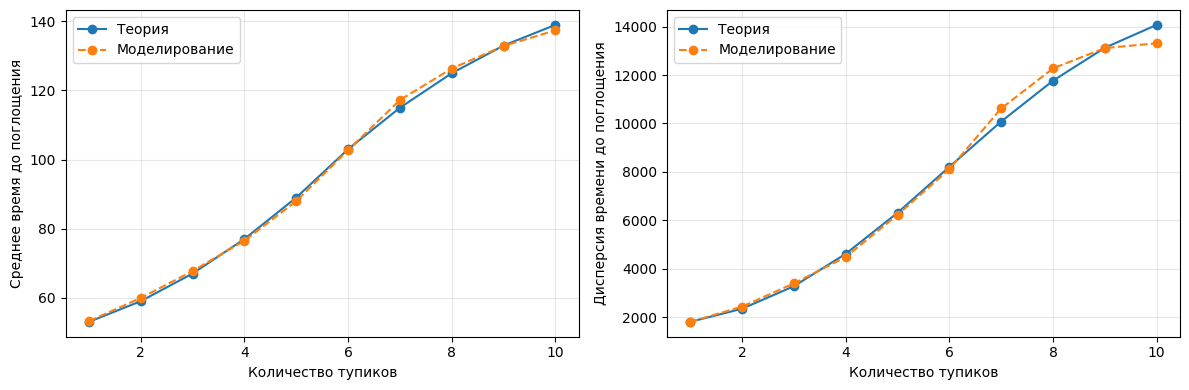

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Среднее время
axes[0].plot(
    results["number_of_dead_ends"],
    results["theory_mean"],
    "o-",
    label="Теория"
)

axes[0].plot(
    results["number_of_dead_ends"],
    results["simulation_mean"],
    "o--",
    label="Моделирование"
)

axes[0].set_xlabel("Количество тупиков")
axes[0].set_ylabel("Среднее время до поглощения")
axes[0].legend()
axes[0].grid(alpha=0.3)


# Дисперсия
axes[1].plot(
    results["number_of_dead_ends"],
    results["theory_variance"],
    "o-",
    label="Теория"
)

axes[1].plot(
    results["number_of_dead_ends"],
    results["simulation_variance"],
    "o--",
    label="Моделирование"
)

axes[1].set_xlabel("Количество тупиков")
axes[1].set_ylabel("Дисперсия времени до поглощения")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(
    "../plots/dead_end_experiment.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()